<a href="https://colab.research.google.com/github/HERO-DS/Computational-Drug-Discovery-LRRK2-gene/blob/main/CDD_ML_Part_5_LRRK2_Compare_Regressors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Comparing Regressors**

several ML algorithms for build regression models of LRRK2 inhibitors will be compared.



## **1. Import libraries**

In [ ]:
!pip install lazypredict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor

## **2. Load the LRRK2 ECFP4 Dataset**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load your LRRK2 ECFP4 dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/LRRK2_06_bioactivity_data_3class_pIC50_ecfp4.csv')

# Separate X (1024 ECFP4 features) and Y (pIC50 target)
X = df.drop('pIC50', axis=1)
Y = df['pIC50']

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

Mounted at /content/drive
X shape: (3783, 1024)
Y shape: (3783,)


## **3. Data pre-processing**

In [ ]:
# Examine X dimension
X.shape

(3783, 1024)

In [ ]:
# 80/20 Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

Train set: (3026, 1024)
Test set:  (757, 1024)


## **4. Compare ML algorithms**

In [ ]:
import numpy as np

# Ensure X and Y are explicit numeric numpy arrays
X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.float32)
Y_test = np.array(Y_test, dtype=np.float32)

print("X_train shape:", X_train.shape, "| Data type:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "| Data type:", Y_train.dtype)

X_train shape: (3026, 1024) | Data type: float32
Y_train shape: (3026,) | Data type: float32


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Ensure numpy arrays are 32-bit floats
X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.float32)
Y_test = np.array(Y_test, dtype=np.float32)

# Define candidate models
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "KNeighbors": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42)
}

results = []

print("Training models...")
for name, model in models.items():
    start_time = time.time()

    # Train
    model.fit(X_train, Y_train)

    # Predict
    preds = model.predict(X_test)
    elapsed = time.time() - start_time

    # Calculate metrics (compatible with all scikit-learn versions)
    r2 = r2_score(Y_test, preds)
    rmse = np.sqrt(mean_squared_error(Y_test, preds))

    results.append({
        "Model": name,
        "R-Squared": r2,
        "RMSE": rmse,
        "Time Taken": elapsed
    })
    print(f"Finished {name:18s} | R²: {r2:.4f} | RMSE: {rmse:.4f} | Time: {elapsed:.2f}s")

# Convert to DataFrame sorted by R-Squared
predictions_test = pd.DataFrame(results).sort_values(by="R-Squared", ascending=False).set_index("Model")

print("\n--- Final Model Leaderboard ---")
display(predictions_test)

Training models...
Finished RandomForest       | R²: 0.7150 | RMSE: 0.5283 | Time: 26.73s
Finished ExtraTrees         | R²: 0.5171 | RMSE: 0.6876 | Time: 21.49s
Finished GradientBoosting   | R²: 0.6253 | RMSE: 0.6057 | Time: 3.17s
Finished Ridge              | R²: 0.5947 | RMSE: 0.6300 | Time: 0.22s
Finished Lasso              | R²: -0.0000 | RMSE: 0.9895 | Time: 0.05s
Finished SVR                | R²: 0.7183 | RMSE: 0.5252 | Time: 4.90s
Finished KNeighbors         | R²: 0.6865 | RMSE: 0.5540 | Time: 0.22s
Finished DecisionTree       | R²: 0.4537 | RMSE: 0.7314 | Time: 0.45s

--- Final Model Leaderboard ---


,R-Squared,RMSE,Time Taken
Model,,,
SVR,0.718327,0.525174,4.898583
RandomForest,0.714973,0.528292,26.734155
KNeighbors,0.686542,0.554014,0.215174
GradientBoosting,0.625313,0.605710,3.168735
Ridge,0.594700,0.629969,0.217979
ExtraTrees,0.517084,0.687649,21.486954
DecisionTree,0.453736,0.731362,0.452243
Lasso,-0.000006,0.989537,0.046924


## **5. Data visualization of model performance**

/tmp/ipykernel_797/1634976403.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=predictions_test, y=predictions_test.index, x="R-Squared", palette="viridis")


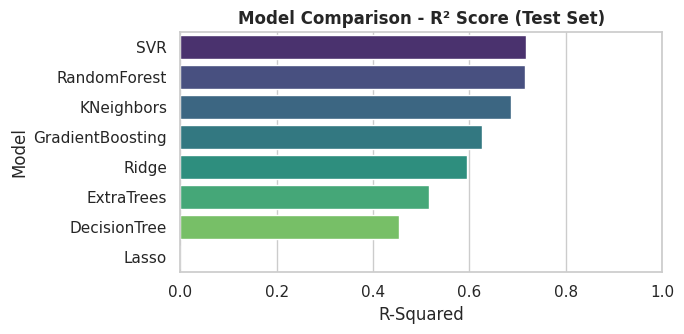

/tmp/ipykernel_797/1634976403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=predictions_test, y=predictions_test.index, x="RMSE", palette="magma")


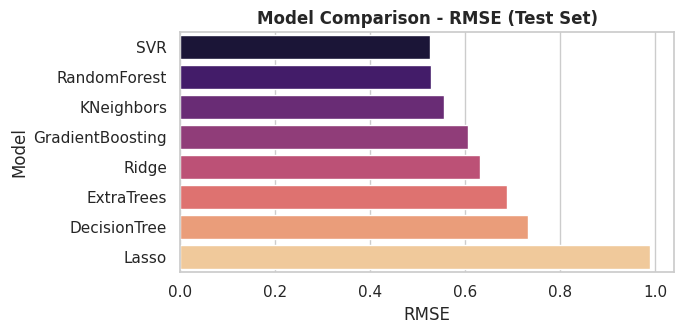

In [ ]:
sns.set_theme(style="whitegrid")

# 1. R-Squared Comparison
plt.figure(figsize=(7, 3.5))
ax1 = sns.barplot(data=predictions_test, y=predictions_test.index, x="R-Squared", palette="viridis")
ax1.set_xlim(0, 1)
ax1.set_title("Model Comparison - R² Score (Test Set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 2. RMSE Comparison
plt.figure(figsize=(7, 3.5))
ax2 = sns.barplot(data=predictions_test, y=predictions_test.index, x="RMSE", palette="magma")
ax2.set_title("Model Comparison - RMSE (Test Set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_797/2938973411.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


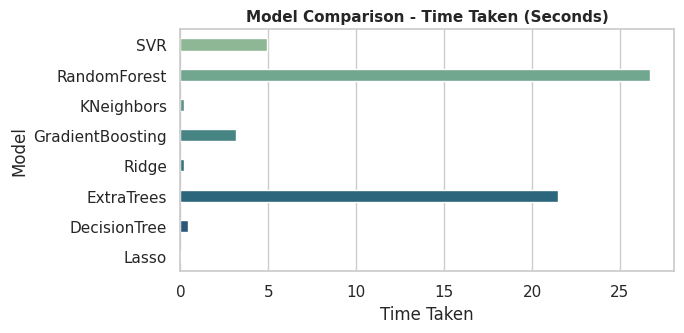

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Bar plot of Time Taken using predictions_test
plt.figure(figsize=(7, 3.5))
ax = sns.barplot(
    data=predictions_test,
    y=predictions_test.index,
    x="Time Taken",
    palette="crest",
    width=0.4
)
ax.set_title("Model Comparison - Time Taken (Seconds)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
import joblib
from sklearn.svm import SVR

# 1. Fit SVR explicitly into its own variable
best_svr_model = SVR()
best_svr_model.fit(X_train, Y_train)

# 2. Save to pickle file for Streamlit
joblib.dump(best_svr_model, 'model.pkl')

print("SVR model trained and saved as 'model.pkl'!")

SVR model trained and saved as 'model.pkl'!
